In [1]:
#Make sure R can find packages installed with Conda
.libPaths('/hb/home/jbos/.conda/envs/vcfR')
.libPaths("/hb/home/jbos/.conda/envs/vcfR/lib/R/library")

In [3]:
library(tidyverse)
library(ape)
library(phangorn)
library(seqinr)
library(viridis)
library(cowplot)
library(grid)
library(gridGraphics)
library(ggtree)

In [4]:
bamnames<-function(bam){
    a<-strsplit(bam,'files/')[[1]][2]
    b<-strsplit(a,'.s')[[1]][1]
    return(b)
    }

In [5]:
angsdpca<-as.matrix(read.table('/scratch/jbos/joint_Acropora/beagles/angsd_acropora_joint.cov'))

In [6]:
bamlist<-read.table('/home/jbos/Moz_scripts/Acropora_bams.txt')
indlist<-apply(bamlist,FUN=bamnames,MARGIN=1)

In [7]:
# Eigen-decomposition and variance explained
eigen1 <- eigen(angsdpca)
eigenvalues <- eigen1$values
eigenvectors <- eigen1$vectors
rownames(eigenvectors)<-indlist
var_explained <- eigenvalues / sum(eigenvalues)
var_explained[1:5]

[1] 0.190717702 0.029144142 0.018411473 0.008344811 0.004125549

In [8]:
#Read in A hyacinthus metadata
sra_runs<-read.csv('/home/jbos/Moz_scripts/Acropora_hyacinthus_pipeline/SraRunTable.csv',header=TRUE)
rose_meta<-read.csv('/home/jbos/Moz_scripts/Acropora_hyacinthus_pipeline/rose_meta.csv',header=TRUE)

In [9]:
#Sort out A hyacinthus species
rose_meta$Library.Name<-rose_meta$filename
hyacinthus_meta<-left_join(sra_runs,rose_meta,by='Library.Name')
hyacinthus_meta$ID<-hyacinthus_meta$Run
hyacinthus_meta<-hyacinthus_meta[,c('ID','cryp')]

In [10]:
#Add A hyacinthus spp to pcangsd data
eigenvectors<-as.data.frame(eigenvectors)
eigenvectors$ID<-c(indlist)
angsdpca_meta<-left_join(eigenvectors,hyacinthus_meta)

Joining with `by = join_by(ID)`


In [11]:
#Sort of Acropora moz species names
mozb_bams<-read.table('/home/jbos/Moz_reads/bam_names_grp1.txt')
inds_mozb<-apply(mozb_bams,FUN=bamnames,MARGIN=1)
mozb<-as.data.frame(matrix(nrow=length(inds_mozb)))
mozb$ID<-inds_mozb
mozb$spp<-'DB'

moznorth_bams<-read.table('/home/jbos/Moz_reads/bam_names_grp7.txt')
inds_moznorth<-apply(moznorth_bams,FUN=bamnames,MARGIN=1)
moznorth<-as.data.frame(matrix(nrow=length(inds_moznorth)))
moznorth$ID<-inds_moznorth
moznorth$spp<-'DA_North'

mozsouth_bams<-read.table('/home/jbos/Moz_reads/bam_names_grp3.txt')
inds_mozsouth<-apply(mozsouth_bams,FUN=bamnames,MARGIN=1)
mozsouth<-as.data.frame(matrix(nrow=length(inds_mozsouth)))
mozsouth$ID<-inds_mozsouth
mozsouth$spp<-'DA_South'

moz_names<-rbind(mozb,moznorth,mozsouth)
moz_names<-moz_names[,c('ID','spp')]

In [12]:
#Add Moz spp/pop names to pcangsd
angsdpca_meta2<-left_join(angsdpca_meta,moz_names,by='ID')

In [13]:
#Add A hyacinthus spp names to same variable
angsdpca_meta2$spp[!is.na(angsdpca_meta2$cryp)]<-angsdpca_meta2$cryp[!is.na(angsdpca_meta2$cryp)]

In [14]:
#Check spp and pop counts
table(angsdpca_meta2$spp)


DA_North DA_South       DB       HA       HC       HD       HE 
      75       86       73       13       23       26       52 

In [15]:
#Read in HES1 data
angsdpca_hes1<-as.matrix(read.table('/scratch/jbos/joint_Acropora/beagles/angsd_hes1_pca.cov'))

In [16]:
#Eigen decomp and variance explained
eigen_hes1 <- eigen(angsdpca_hes1)
eigenvalues_hes1 <- eigen_hes1$values
eigenvectors_hes1 <- eigen_hes1$vectors
var_explained_hes1  <- eigenvalues_hes1  / sum(eigenvalues_hes1 )
var_explained_hes1 [1:8]
eigenvectors_hes1<-as.data.frame(eigenvectors_hes1)
eigenvectors_hes1$ID<-c(indlist)

[1] 0.140434901 0.075995138 0.060244830 0.038307440 0.028695455 0.023132547
[7] 0.008431119 0.007491142

In [17]:
#Stick to metadata to get spp definitions
angsdpca_meta_hes1<-left_join(eigenvectors_hes1,hyacinthus_meta)
angsdpca_meta_hes1<-left_join(angsdpca_meta_hes1,moz_names,by='ID')
angsdpca_meta_hes1$spp[!is.na(angsdpca_meta2$cryp)]<-angsdpca_meta_hes1$cryp[!is.na(angsdpca_meta2$cryp)]

Joining with `by = join_by(ID)`


In [18]:
#Read in PCANGSD for gene 1
angsdpca_gene1<-as.matrix(read.table('/scratch/jbos/joint_Acropora/beagles/angsd_hes1_LOC114955281_pca.cov'))

In [19]:
#Calculate variance explained,etc
eigen_gene1 <- eigen(angsdpca_gene1)
eigenvalues_gene1 <- eigen_gene1$values
eigenvectors_gene1 <- eigen_gene1$vectors
var_explained_gene1  <- eigenvalues_gene1  / sum(eigenvalues_gene1)
var_explained_gene1 [1:8]

[1] 0.18525923 0.13278375 0.08410852 0.06231797 0.02463737 0.01871354 0.01539511
[8] 0.01387715

In [20]:
#Sort out spp names
eigenvectors_gene1<-as.data.frame(eigenvectors_gene1)
eigenvectors_gene1$ID<-c(indlist)
angsdpca_meta_gene1<-left_join(eigenvectors_gene1,hyacinthus_meta)
angsdpca_meta_gene1<-left_join(angsdpca_meta_gene1,moz_names,by='ID')
angsdpca_meta_gene1$spp[!is.na(angsdpca_meta_gene1$cryp)]<-angsdpca_meta_gene1$cryp[!is.na(angsdpca_meta_gene1$cryp)]

Joining with `by = join_by(ID)`


In [21]:
#Read in PCANGSD for noncoding region
angsdpca_noncoding1<-as.matrix(read.table('/scratch/jbos/joint_Acropora/beagles/angsd_hes1_noncoding2_pca.cov'))

In [22]:
#Eigenvalues, var explained
eigen_noncod1 <- eigen(angsdpca_noncoding1)
eigenvalues_noncod1 <- eigen_noncod1$values
eigenvectors_noncod1 <- eigen_noncod1$vectors
var_explained_noncod1  <- eigenvalues_noncod1 / sum(eigenvalues_noncod1)
var_explained_noncod1[1:8]

[1] 0.14548082 0.09859320 0.07778416 0.05575827 0.03077205 0.02663343 0.02542364
[8] 0.02263683

In [23]:
#Spp IDs
eigenvectors_noncod1<-as.data.frame(eigenvectors_noncod1)
eigenvectors_noncod1$ID<-c(indlist)
angsdpca_meta_noncod1<-left_join(eigenvectors_noncod1,hyacinthus_meta)
angsdpca_meta_noncod1<-left_join(angsdpca_meta_noncod1,moz_names,by='ID')
angsdpca_meta_noncod1$spp[!is.na(angsdpca_meta_noncod1$cryp)]<-angsdpca_meta_noncod1$cryp[!is.na(angsdpca_meta_noncod1$cryp)]

Joining with `by = join_by(ID)`


In [24]:
#Read in PCANGSD for gene 2
angsdpca_gene2<-as.matrix(read.table('/scratch/jbos/joint_Acropora/beagles/angsd_hes1_LOC114955285_pca.cov'))

In [25]:
#Calculate variance explained,etc
eigen_gene2 <- eigen(angsdpca_gene2)
eigenvalues_gene2 <- eigen_gene2$values
eigenvectors_gene2 <- eigen_gene2$vectors
var_explained_gene2  <- eigenvalues_gene2  / sum(eigenvalues_gene2)
var_explained_gene2[1:8]

[1] 0.17109761 0.10059733 0.06730254 0.05896326 0.02171362 0.01791073 0.01489892
[8] 0.01156086

In [26]:
#Sort out spp names
eigenvectors_gene2<-as.data.frame(eigenvectors_gene2)
eigenvectors_gene2$ID<-c(indlist)
angsdpca_meta_gene2<-left_join(eigenvectors_gene2,hyacinthus_meta)
angsdpca_meta_gene2<-left_join(angsdpca_meta_gene2,moz_names,by='ID')
angsdpca_meta_gene2$spp[!is.na(angsdpca_meta_gene2$cryp)]<-angsdpca_meta_gene2$cryp[!is.na(angsdpca_meta_gene2$cryp)]

Joining with `by = join_by(ID)`


In [27]:
wholegenome_dna <- read.dna("/scratch/jbos/Acropora_hyacinthus/consensus_fastas_whole/Acropora_aligned_small.fasta", format = "fasta")

In [28]:
hes1_dna <- read.dna("/scratch/jbos/mafft_alignments_wholegenome/hes1_rose.aln", format = "fasta")
gene1_dna <- read.dna("/scratch/jbos/mafft_alignments_wholegenome/gene1.aln", format = "fasta")
gene2_dna <- read.dna("/scratch/jbos/mafft_alignments_wholegenome/gene2.aln", format = "fasta")
noncoding_dna <- read.dna("/scratch/jbos/mafft_alignments_wholegenome/noncoding2.aln", format = "fasta")

In [29]:
rownames(wholegenome_dna)<-c('A_mil','DA_north','DA_south','DB*****','HA','HC','HD','HE*****','Isopora')
rownames(hes1_dna)<-c('A_mil','DA_north','DA_south','DB*****','HA','HC','HD','HE*****','Isopora')
rownames(gene1_dna)<-c('A_mil','DA_north','DA_south','DB*****','HA','HC','HD','HE*****','Isopora')
rownames(gene2_dna)<-c('A_mil','DA_north','DA_south','DB*****','HA','HC','HD','HE*****','Isopora')
rownames(noncoding_dna)<-c('A_mil','DA_north','DA_south','DB*****','HA','HC','HD','HE*****','Isopora')

In [30]:
wholegenome_dna

9 DNA sequences in binary format stored in a matrix.

All sequences of same length: 4753194 

Labels:
A_mil
DA_north
DA_south
DB*****
HA
HC
...

More than 10 million bases: not printing base composition.
(Total: 42.78 Mb)

In [31]:
wholegenome_dna2<-wholegenome_dna[2:9,]
hes1_dna2<-hes1_dna[2:9,]
gene1_dna2<-gene1_dna[2:9,]
gene2_dna2<-gene2_dna[2:9,]
noncoding_dna2<-noncoding_dna[2:9,]

In [32]:
rownames(wholegenome_dna2)

[1] "DA_north" "DA_south" "DB*****"  "HA"       "HC"       "HD"       "HE*****" 
[8] "Isopora"

In [33]:
dna_dist_all <- dist.dna(wholegenome_dna2,model = "K80")

In [34]:
# Compute distance matrix
dna_dist_hes1 <- dist.dna(hes1_dna2, model = "K80")
dna_dist_gene1 <- dist.dna(gene1_dna2, model = "K80")
dna_dist_noncoding <- dist.dna(noncoding_dna2, model = "K80")
dna_dist_gene2 <- dist.dna(gene2_dna2, model = "K80")

In [35]:
attr(dna_dist_all, "Labels") <-c('DA_north','DA_south','DB*****','HA','HC','HD','HE*****','Isopora')
attr(dna_dist_hes1, "Labels") <-c('DA_north','DA_south','DB*****','HA','HC','HD','HE*****','Isopora')
attr(dna_dist_gene1, "Labels") <-c('DA_north','DA_south','DB*****','HA','HC','HD','HE*****','Isopora')
attr(dna_dist_noncoding, "Labels") <-c('DA_north','DA_south','DB*****','HA','HC','HD','HE*****','Isopora')
attr(dna_dist_gene2, "Labels") <-c('DA_north','DA_south','DB*****','HA','HC','HD','HE*****','Isopora')

In [36]:
# Build balanced minimum evolution trees
tree_all_me <- fastme.bal(dna_dist_all)

In [37]:
# Build balanced minimum evolution trees
tree_hes1_me <- fastme.bal(dna_dist_hes1)
tree_gene1_me <- fastme.bal(dna_dist_gene1)
tree_noncoding_me <- fastme.bal(dna_dist_noncoding)
tree_gene2_me <- fastme.bal(dna_dist_gene2)

In [38]:
tree_all_rooted <- root(tree_all_me,outgroup='Isopora')
tree_hes1_rooted <- root(tree_hes1_me,outgroup='Isopora')
tree_gene1_rooted <- root(tree_gene1_me,outgroup='Isopora')
tree_noncoding_rooted <- root(tree_noncoding_me,outgroup='Isopora')
tree_gene2_rooted <- root(tree_gene2_me,outgroup='Isopora')

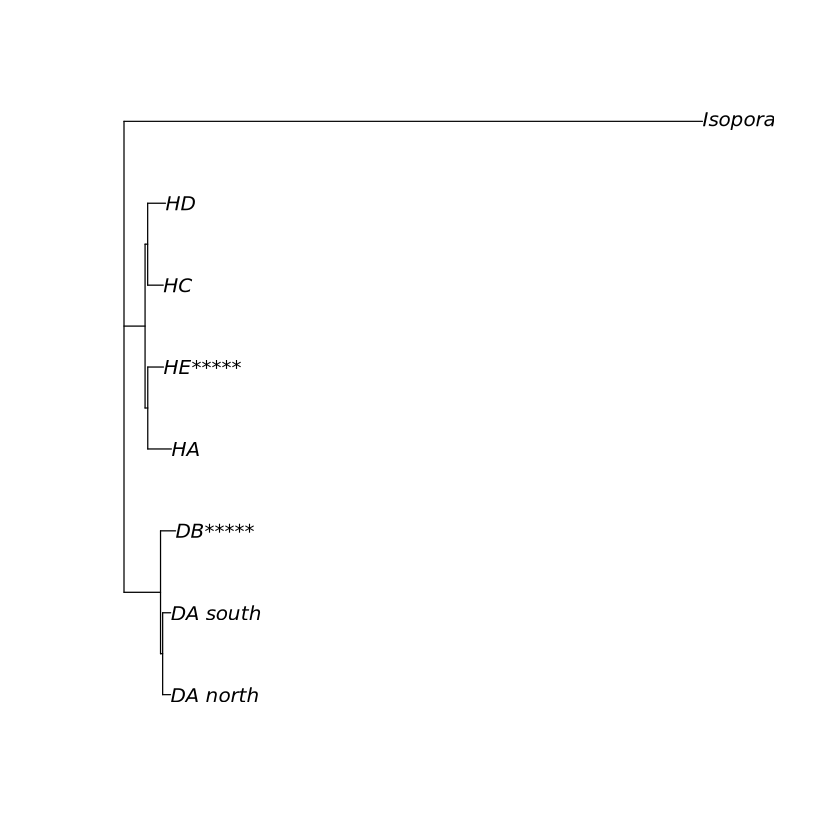

In [39]:
plot(tree_all_rooted, type = "phylogram")

In [40]:
tree_hes1_rooted <- root(tree_hes1_me,outgroup='Isopora')
tree_gene1_rooted <- root(tree_gene1_me,outgroup='Isopora')
tree_noncoding_rooted <- root(tree_noncoding_me,outgroup='Isopora')
tree_gene2_rooted <- root(tree_gene2_me,outgroup='Isopora')

In [41]:
table(angsdpca_meta2$spp)


DA_North DA_South       DB       HA       HC       HD       HE 
      75       86       73       13       23       26       52 

In [42]:
tree_builder <- function(x) {
  tr<-fastme.bal(dist.dna(x))
  root(tr,outgroup='Isopora')
}

In [43]:
#Bootstrap
set.seed(42)
big_boot<-boot.phylo(tree_all_rooted,wholegenome_dna2,tree_builder,B=1000,trees=TRUE)

In [ ]:
#Bootstrap
set.seed(42)
hes1_boot<-boot.phylo(tree_hes1_rooted,hes1_dna2,tree_builder,B=1000,trees=TRUE)
gene1_boot<-boot.phylo(tree_gene1_rooted,gene1_dna2,tree_builder,B=1000,trees=TRUE)
noncoding_boot<-boot.phylo(tree_noncoding_rooted,noncoding_dna2,tree_builder,B=1000,trees=TRUE)
gene2_boot<-boot.phylo(tree_gene2_rooted,gene2_dna2,tree_builder,B=1000,trees=TRUE)

In [ ]:
clades_all<-prop.clades(tree_all_rooted, big_boot$trees, rooted=TRUE)
clades_all

In [44]:
clades_all<-c(1000,767,1000,1000,800,746)

In [60]:
clades_hes1 <- prop.clades(tree_hes1_rooted, hes1_boot$trees, rooted=TRUE)
clades_gene1 <- prop.clades(tree_gene1_rooted, gene1_boot$trees, rooted=TRUE)
clades_noncoding <- prop.clades(tree_noncoding_rooted, noncoding_boot$trees, rooted=TRUE)
clades_gene2 <- prop.clades(tree_gene2_rooted, gene2_boot$trees, rooted=TRUE)

In [61]:
clades_hes1
clades_gene1
clades_noncoding
clades_gene2

[1] 1000 1000  977  942  866  527

[1] 1000  967  847  438  472  176

[1] 1000  433  890  631  845  631

[1] 1000  947  953  964  998  686

In [45]:
clades_hes1<-c(1000,1000,977,942,866,527)
clades_gene1<-c(1000,967,847,438,472,176)
clades_noncoding<-c(1000,433,890,631,845,631)
clades_gene2<-c(1000,947,953,964,998,686)

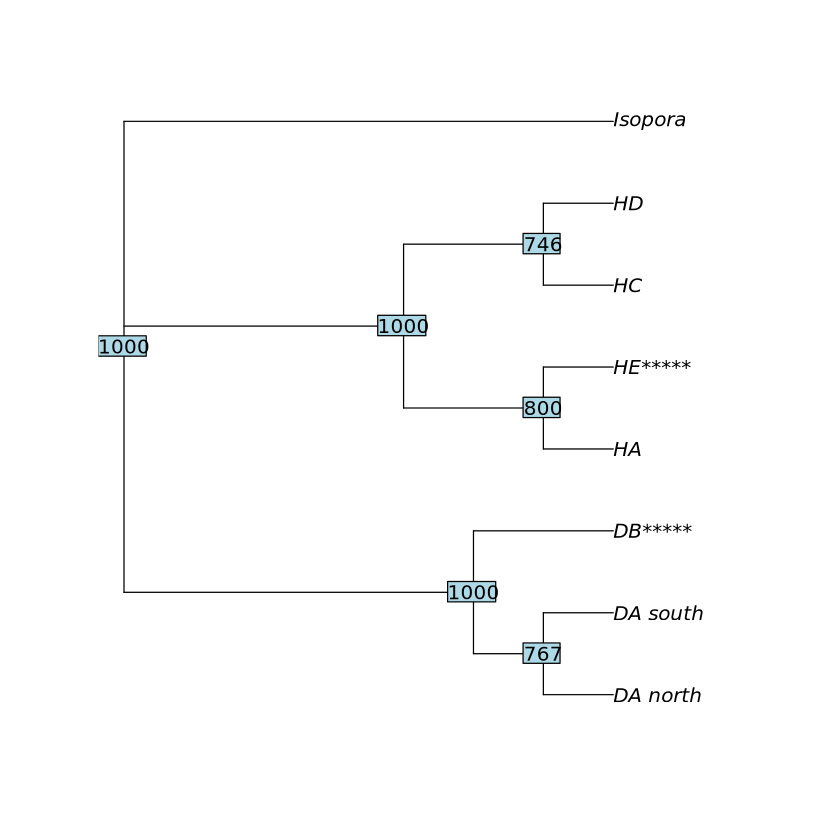

In [46]:
plot(tree_all_rooted,use.edge.length=FALSE)
nodelabels(clades_all)

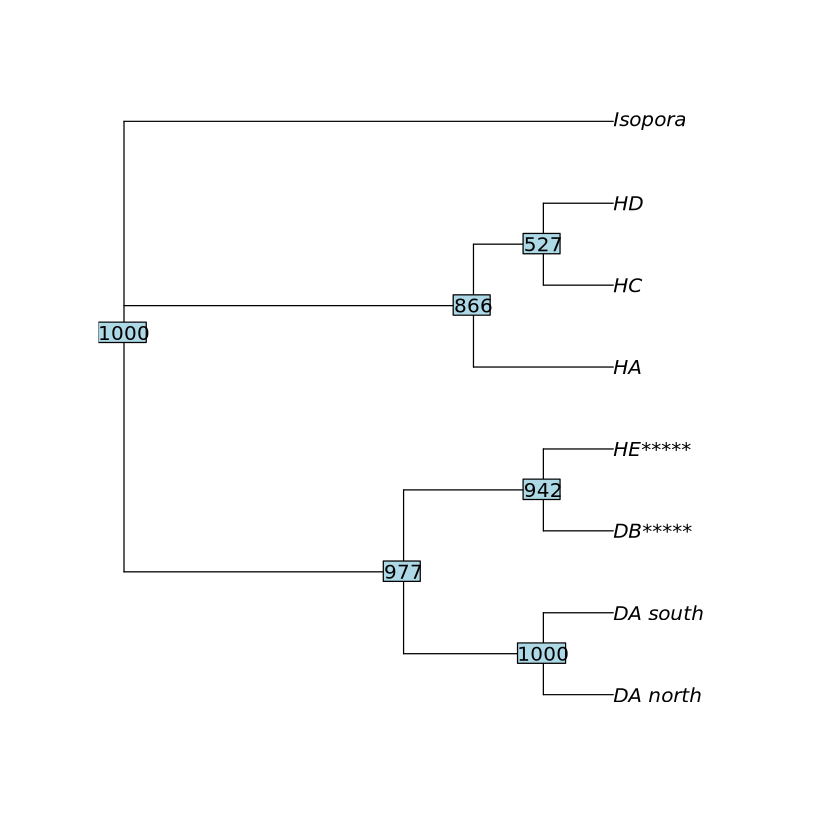

In [47]:
plot(tree_hes1_rooted,use.edge.length=FALSE)
nodelabels(clades_hes1)

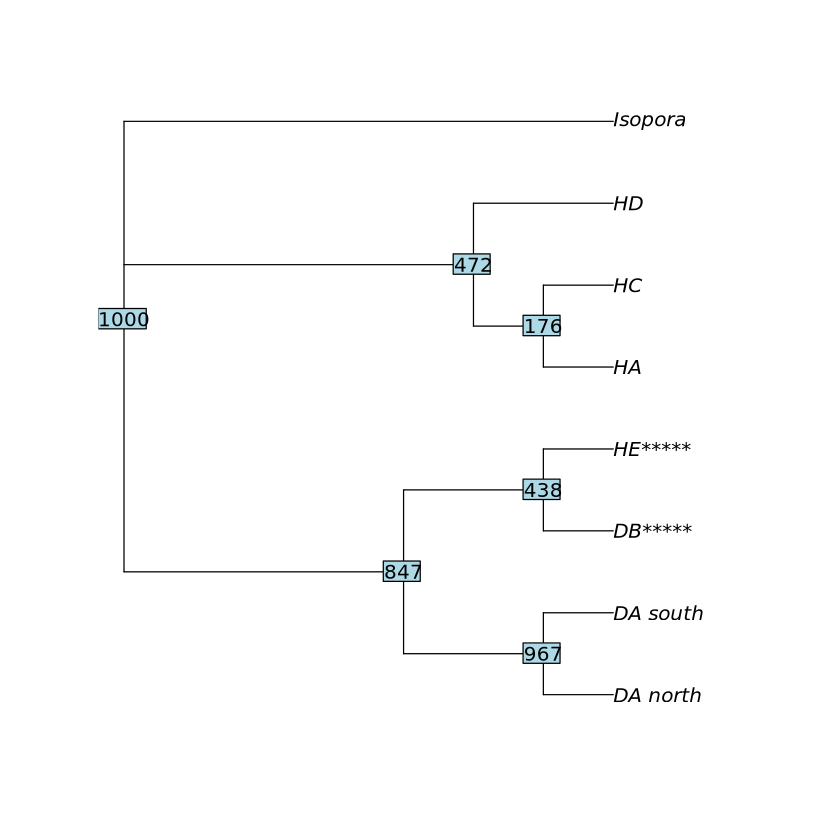

In [48]:
plot(tree_gene1_rooted,use.edge.length=FALSE)
nodelabels(clades_gene1)

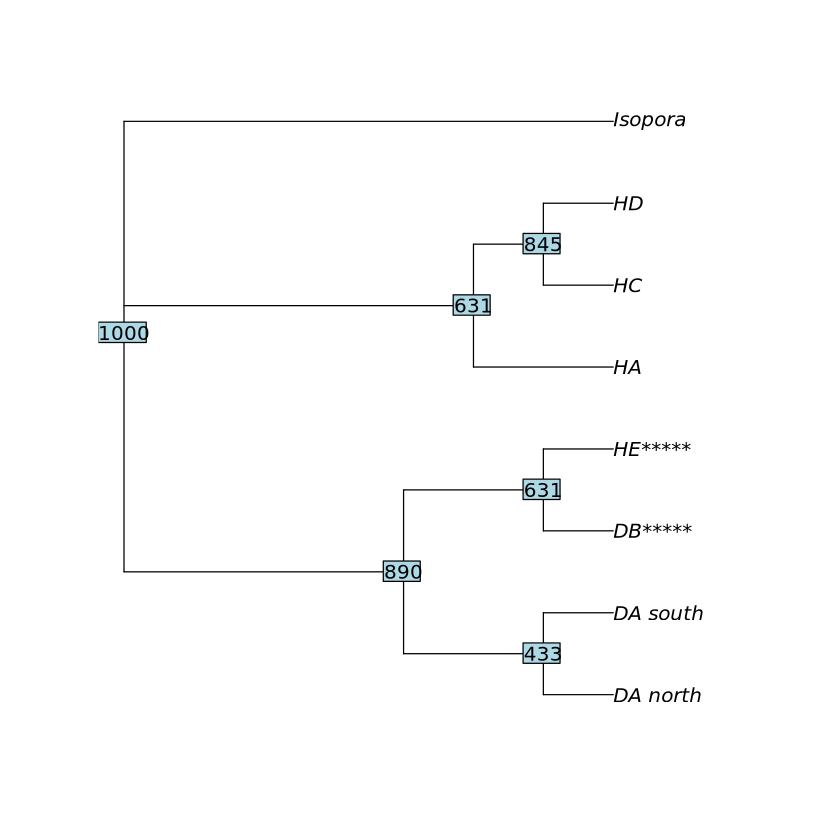

In [49]:
plot(tree_noncoding_rooted,use.edge.length=FALSE)
nodelabels(clades_noncoding)

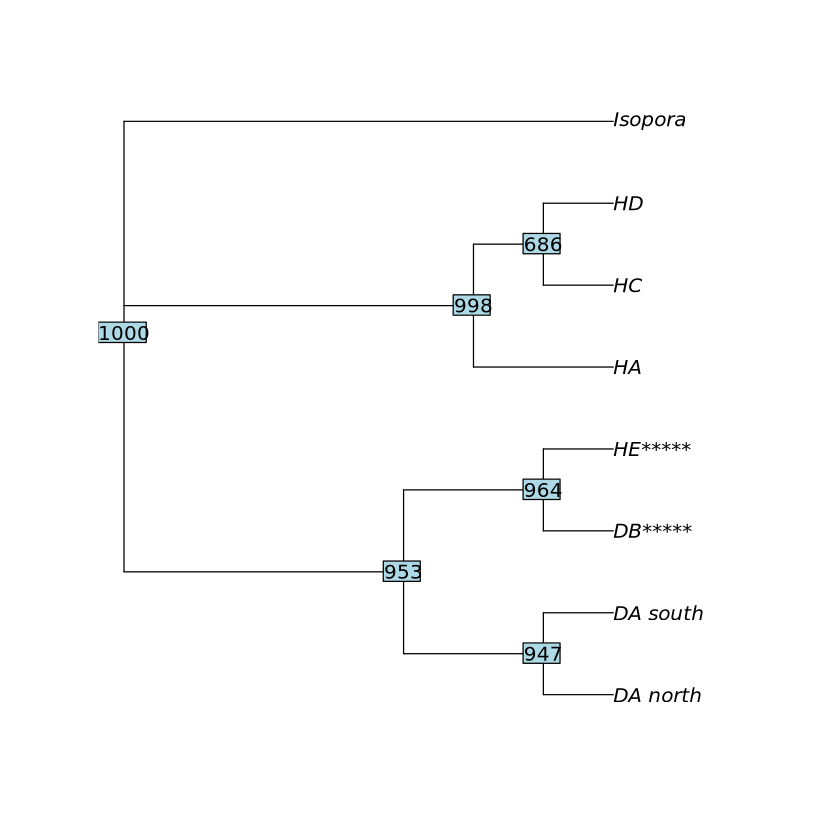

In [50]:
plot(tree_gene2_rooted,use.edge.length=FALSE)
nodelabels(clades_gene2)

In [53]:
tree_all_rooted$node.label <- round(clades_all/1000,2)
tree_hes1_rooted$node.label <- round(clades_hes1/1000,2)
tree_gene1_rooted$node.label <- round(clades_gene1/1000,2)
tree_noncoding_rooted$node.label <- round(clades_noncoding/1000,2)
tree_gene2_rooted$node.label <- round(clades_gene2/1000,2)

In [54]:
species_colors <- c(
  "HA" = "#31688e",
  "HC" = "#443983",
  "HD" = "#440154",
  "HE" = "#D40078",
  "DA_North" = "#90d743",
  "DA_South" = "#35b779",
  "DB" = "#fde725"
)

Warning message in fortify(data, ...):
“Arguments in `...` must be used.
✖ Problematic arguments:
• as.Date = as.Date
• yscale_mapping = yscale_mapping
• hang = hang
ℹ Did you misspell an argument name?”
Warning message in label_geom(mapping = structure(list(x = ~x + diff(range(x, na.rm = TRUE))/200, :
“Ignoring unknown parameters: `label.size`”
Warning message in fortify(data, ...):
“Arguments in `...` must be used.
✖ Problematic arguments:
• as.Date = as.Date
• yscale_mapping = yscale_mapping
• hang = hang
ℹ Did you misspell an argument name?”
Warning message in label_geom(mapping = structure(list(x = ~x + diff(range(x, na.rm = TRUE))/200, :
“Ignoring unknown parameters: `label.size`”
Warning message in fortify(data, ...):
“Arguments in `...` must be used.
✖ Problematic arguments:
• as.Date = as.Date
• yscale_mapping = yscale_mapping
• hang = hang
ℹ Did you misspell an argument name?”
Warning message in label_geom(mapping = structure(list(x = ~x + diff(range(x, na.rm = TRUE))/200, :


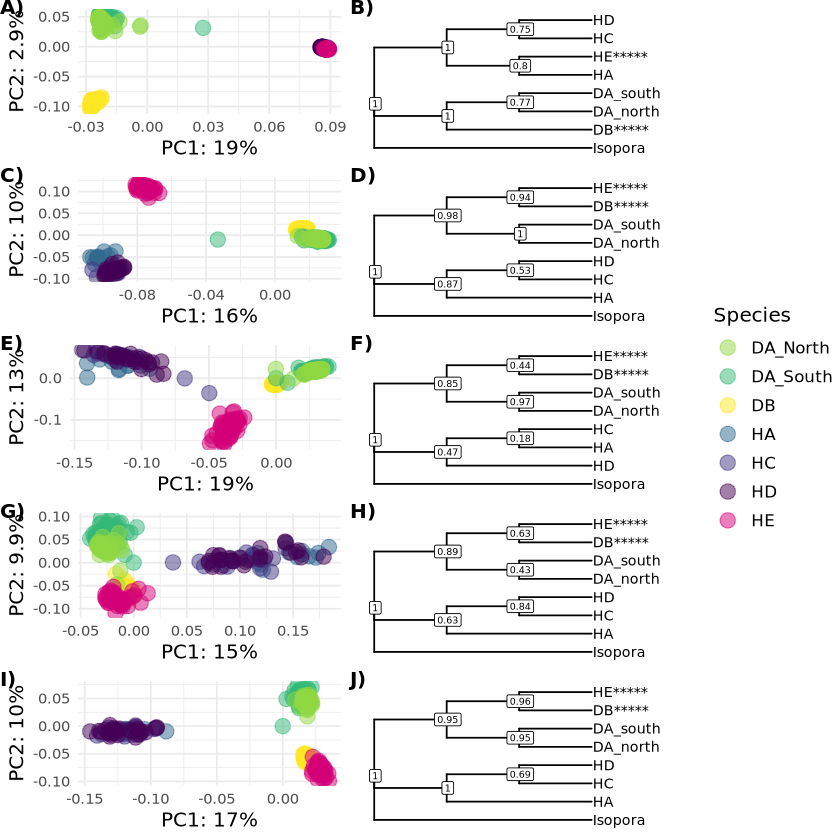

In [56]:
# Create the ten plots
plot_a <- ggplot(angsdpca_meta2, aes(x=V1, y=V2, color=spp)) +
  geom_point(shape=19, size=4, alpha=0.5) +
  labs(x='PC1: 19%', y='PC2: 2.9%', color="Species") + 
  scale_color_manual(values=species_colors) +
  theme_minimal() +
  theme(axis.title = element_text(size = 12), 
        legend.position = "none")

plot_b <- ggtree(tree_all_rooted,branch.length = "none") +
  geom_tiplab(size = 3) +
  theme_tree2() +
  geom_nodelab(aes(label = label), geom="label", size=2,fill= "white",node= "internal") +  
theme(axis.title.x = element_blank(),
        axis.text.x = element_blank(),
        axis.ticks.x = element_blank(),
        axis.line.x = element_blank())+
  hexpand(0.3, direction = 1)

plot_c <- ggplot(angsdpca_meta_hes1, aes(x=V1, y=V2, color=spp)) +
  geom_point(shape=19, size=4, alpha=0.5) +
  labs(x='PC1: 16%', y='PC2: 10%', color="Species") +
  scale_color_manual(values=species_colors) +
  theme_minimal() +
  theme(axis.title = element_text(size = 12), 
        legend.position = "none")

plot_d <- ggtree(tree_hes1_rooted,branch.length = "none") +
  geom_tiplab(size = 3) +
  theme_tree2() +
  geom_nodelab(aes(label = label), geom="label", size=2,fill= "white",node= "internal") +  
theme(axis.title.x = element_blank(),
        axis.text.x = element_blank(),
        axis.ticks.x = element_blank(),
        axis.line.x = element_blank())+
  hexpand(0.3, direction = 1)

plot_e <- ggplot(angsdpca_meta_gene1, aes(x=V1, y=V2, color=spp)) +
  geom_point(shape=19, size=4, alpha=0.5) +
  labs(x='PC1: 19%', y='PC2: 13%', color="Species") + 
  scale_color_manual(values=species_colors) +
  theme_minimal() +
  theme(axis.title = element_text(size = 12), 
        legend.position = "none")

plot_f <- ggtree(tree_gene1_rooted,branch.length = "none") +
  geom_tiplab(size = 3) +
  theme_tree2() +
  geom_nodelab(aes(label = label), geom="label", size=2,fill= "white",node= "internal") +  
  theme(axis.title.x = element_blank(),
        axis.text.x = element_blank(),
        axis.ticks.x = element_blank(),
        axis.line.x = element_blank())+
  hexpand(0.3, direction = 1)

plot_g <- ggplot(angsdpca_meta_noncod1, aes(x=V1, y=V2, color=spp)) +
  geom_point(shape=19, size=4, alpha=0.5) +
  labs(x='PC1: 15%', y='PC2: 9.9%', color="Species") +
  scale_color_manual(values=species_colors) +
  theme_minimal() +
  theme(axis.title = element_text(size = 12), 
        legend.position = "none")

plot_h <- ggtree(tree_noncoding_rooted,branch.length = "none") +
  geom_tiplab(size = 3) +
  theme_tree2() +
  geom_nodelab(aes(label = label), geom="label", size=2,fill= "white",node= "internal") +  
  theme(axis.title.x = element_blank(),
        axis.text.x = element_blank(),
        axis.ticks.x = element_blank(),
        axis.line.x = element_blank())+
  hexpand(0.3, direction = 1)

plot_i <- ggplot(angsdpca_meta_gene2, aes(x=V1, y=V2, color=spp)) +
  geom_point(shape=19, size=4, alpha=0.5) +
  labs(x='PC1: 17%', y='PC2: 10%', color="Species") + 
  scale_color_manual(values=species_colors) +
  theme_minimal() +
  theme(axis.title = element_text(size = 12), 
        legend.position = "none")

plot_j <- ggtree(tree_gene2_rooted,branch.length = "none") +
  geom_tiplab(size = 3) +
  theme_tree2() +
  geom_nodelab(aes(label = label), geom="label", size=2,fill= "white",node= "internal") +  
  theme(axis.title.x = element_blank(),
        axis.text.x = element_blank(),
        axis.ticks.x = element_blank(),
        axis.line.x = element_blank())+
  hexpand(0.3, direction = 1)

legend_plot <- plot_a +
  theme(legend.position = "right",
        legend.title = element_text(size = 12),
        legend.text  = element_text(size = 10))

legend <- get_legend(legend_plot)

main_grid <- plot_grid(
  plot_a, NULL, plot_b,
  plot_c, NULL, plot_d,
  plot_e, NULL, plot_f,
  plot_g, NULL, plot_h,
  plot_i, NULL, plot_j,
  ncol = 3,
  nrow = 5,
  labels = c("A)", "", "B)", "C)", "", "D)", "E)", "", "F)", "G)", "", "H)", "I)", "", "J)"),
  label_size = 12,
  label_x = 0, label_y = 1,
  hjust = 0, vjust = 1,
  rel_widths = c(1, 0, 1),
  rel_heights = c(1, 1, 1, 1, 1)
)
combined_plot <- plot_grid(
  main_grid, legend,
  ncol = 2,
  rel_widths = c(1, 0.2)   
)

combined_plot
ggsave("Acropora_Moz_fig5_update.jpg", combined_plot, width = 8, height = 12, dpi = 800)